<a href="https://colab.research.google.com/github/Mrunmayeethakur-2004/AI_Course_Assignments/blob/main/Project_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Get Dataset

In [1]:
!pip install -q transformers kaggle
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/mohitgupta-1O1/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"
df = pd.read_csv(url, encoding='latin-1')
print(df.shape)
df.head()

(5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# EDA

In [3]:
print(df.columns.tolist())

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [4]:
df = df.rename(columns={df.columns[0]: 'label', df.columns[1]: 'text'})
df = df[['label', 'text']].dropna()

print("Shape after dropping NaNs:", df.shape)
print("\nClass distribution:")
print(df['label'].value_counts())
print("\nClass distribution (%):")
print(df['label'].value_counts(normalize=True) * 100)

Shape after dropping NaNs: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class distribution (%):
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [5]:
n_dupes = df.duplicated(subset=['text']).sum()
print(f"Duplicate text rows: {n_dupes} ({n_dupes/len(df)*100:.2f}%)")
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print("Shape after deduplication:", df.shape)

df['label'] = df['label'].str.lower().map({'ham': 0, 'spam': 1})
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

Duplicate text rows: 403 (7.23%)
Shape after deduplication: (5169, 2)


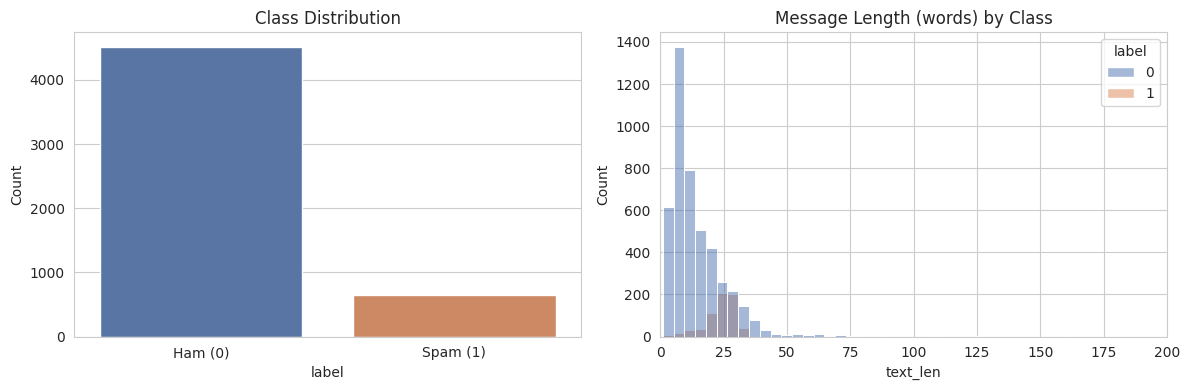

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='label', data=df, ax=axes[0], palette=['#4C72B0', '#DD8452'])
axes[0].set_xticklabels(['Ham (0)', 'Spam (1)'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

sns.histplot(data=df, x='text_len', hue='label', bins=40, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Message Length (words) by Class')
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

# Train/Val/Test split

In [7]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    df['text'], df['label'], test_size=0.15, stratify=df['label'], random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42  # ≈15% of total
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print("Train class balance:\n", y_train.value_counts(normalize=True))

Train: 3617  Val: 776  Test: 776
Train class balance:
 label
0    0.873652
1    0.126348
Name: proportion, dtype: float64


# Part A — Traditional ML                                                     (Text preprocessing)                                                     

In [8]:
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)
    text = re.sub(r'\d+', ' NUM ', text)
    text = re.sub(r'[^a-zA-Z!$ ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

print("Before:", X_train.iloc[0][:120])
print("After :", X_train_clean.iloc[0][:120])

Before: Wat's my dear doing? Sleeping ah?
After : wat dear sleeping ah


# TF-IDF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (3617, 5000)


# Logistic Regression + Naive Bayes

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time

results = {}
conf_matrices = {}
train_times = {}

# --- Logistic Regression ---
t0 = time.time()
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_tfidf, y_train)
train_times['Logistic Regression'] = time.time() - t0

y_pred_lr = lr.predict(X_test_tfidf)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
}
conf_matrices['Logistic Regression'] = confusion_matrix(y_test, y_pred_lr)

# --- Naive Bayes ---
t0 = time.time()
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
train_times['Naive Bayes'] = time.time() - t0

y_pred_nb = nb.predict(X_test_tfidf)
results['Naive Bayes'] = {
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'precision': precision_score(y_test, y_pred_nb),
    'recall': recall_score(y_test, y_pred_nb),
    'f1': f1_score(y_test, y_pred_nb),
}
conf_matrices['Naive Bayes'] = confusion_matrix(y_test, y_pred_nb)

for name, m in results.items():
    print(f"\n{name}")
    for k, v in m.items():
        print(f"  {k}: {v:.4f}")


Logistic Regression
  accuracy: 0.9704
  precision: 0.8440
  recall: 0.9388
  f1: 0.8889

Naive Bayes
  accuracy: 0.9807
  precision: 1.0000
  recall: 0.8469
  f1: 0.9171


# Part B — DistilBERT

Tokenization + Dataset

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = SpamDataset(X_train, y_train, tokenizer)
val_ds = SpamDataset(X_val, y_val, tokenizer)
test_ds = SpamDataset(X_test, y_test, tokenizer)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

# Model, freezing strategy, optimizer

In [12]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False
for layer in model.distilbert.transformer.layer[:2]:
    for param in layer.parameters():
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 28,943,618 / 66,955,010 (43.2%)


In [13]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn

EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)
loss_fn = nn.CrossEntropyLoss()

# Custom training loop

In [14]:
from sklearn.metrics import f1_score as sk_f1

def evaluate(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = sk_f1(all_labels, all_preds)
    return total_loss / len(loader), acc, f1, all_preds, all_labels

history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0
t0 = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_distilbert.pt')

bert_train_time = time.time() - t0
train_times['DistilBERT'] = bert_train_time
print(f"\nTotal training time: {bert_train_time:.1f}s")

Epoch 1/3 | train_loss=0.1608 | val_loss=0.0509 | val_acc=0.9871 | val_f1=0.9479
Epoch 2/3 | train_loss=0.0337 | val_loss=0.0535 | val_acc=0.9884 | val_f1=0.9534
Epoch 3/3 | train_loss=0.0186 | val_loss=0.0554 | val_acc=0.9871 | val_f1=0.9479

Total training time: 98.5s


# Final test evaluation (DistilBERT)

In [15]:
model.load_state_dict(torch.load('best_distilbert.pt'))
_, test_acc, test_f1, y_pred_bert, y_true_bert = evaluate(model, test_loader)

results['DistilBERT'] = {
    'accuracy': accuracy_score(y_true_bert, y_pred_bert),
    'precision': precision_score(y_true_bert, y_pred_bert),
    'recall': recall_score(y_true_bert, y_pred_bert),
    'f1': f1_score(y_true_bert, y_pred_bert),
}
conf_matrices['DistilBERT'] = confusion_matrix(y_true_bert, y_pred_bert)

print(results['DistilBERT'])

{'accuracy': 0.9884020618556701, 'precision': 0.9587628865979382, 'recall': 0.9489795918367347, 'f1': 0.9538461538461539}


# Visualizations

**Metric comparison:**

                     accuracy  precision    recall        f1
Logistic Regression  0.970361   0.844037  0.938776  0.888889
Naive Bayes          0.980670   1.000000  0.846939  0.917127
DistilBERT           0.988402   0.958763  0.948980  0.953846


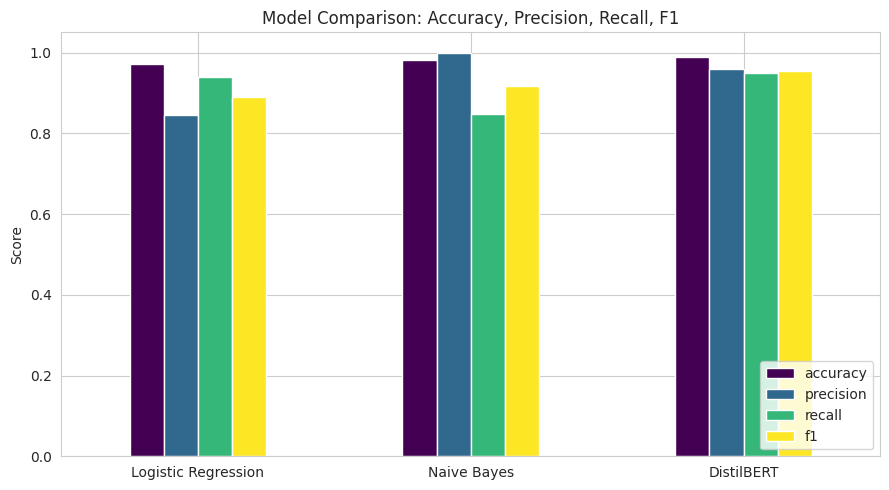

In [16]:
import numpy as np

metrics_df = pd.DataFrame(results).T
print(metrics_df)

metrics_df.plot(kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Model Comparison: Accuracy, Precision, Recall, F1')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=150)
plt.show()

**Confusion matrices:**

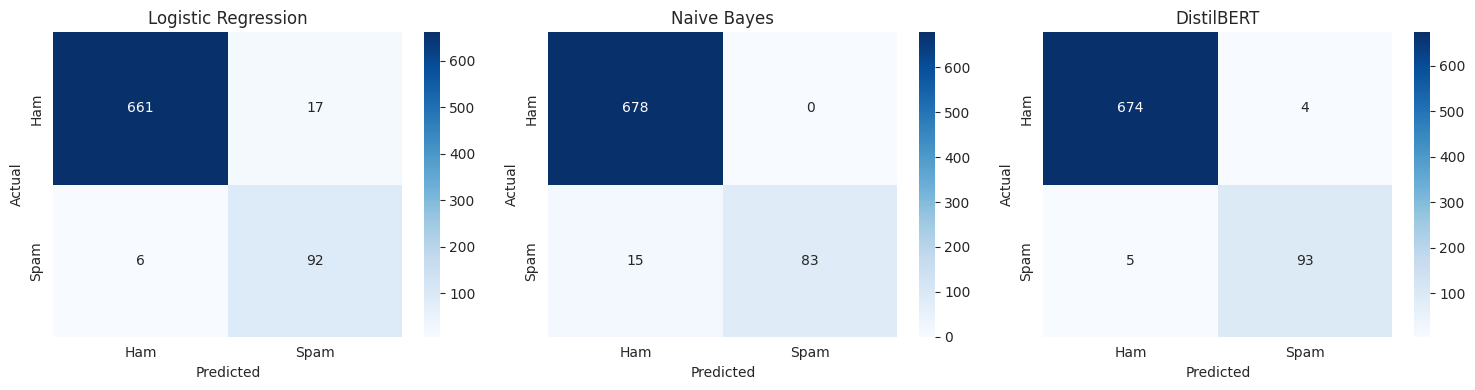

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

**DistilBERT training curves:**

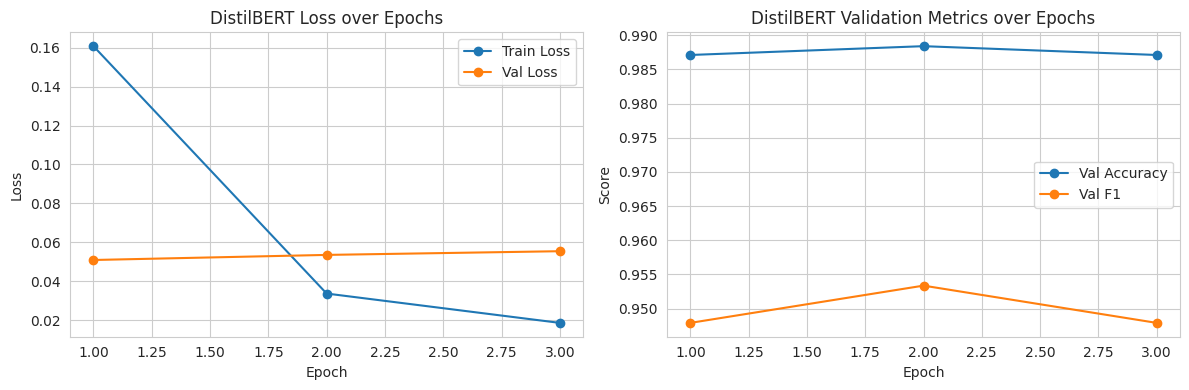

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('DistilBERT Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'], marker='o', label='Val Accuracy')
axes[1].plot(epochs_range, history['val_f1'], marker='o', label='Val F1')
axes[1].set_title('DistilBERT Validation Metrics over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

**Training time comparison:**

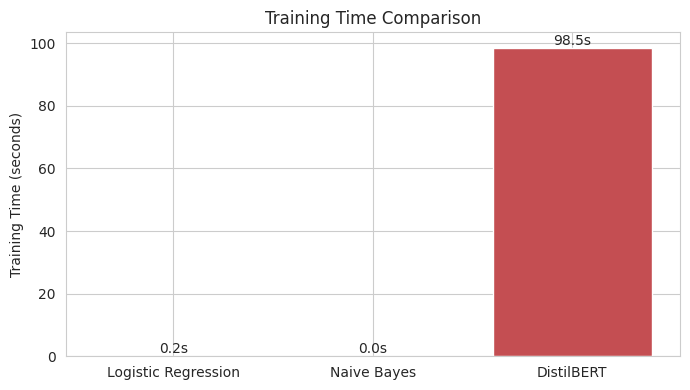

In [19]:
plt.figure(figsize=(7, 4))
names = list(train_times.keys())
times = list(train_times.values())
bars = plt.bar(names, times, color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison')
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{t:.1f}s', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('training_time_comparison.png', dpi=150)
plt.show()